# Binary Classification with CNNs: Kaggle Data Set
With GlobalAveragePooling layers and AdamW, early stopping on PR-AUC, decision threshold tuning, and NO transfer learning from the pneumonia MNIST data set or image resizing

## Setup

In [1]:
import datetime

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import precision_recall_curve

notebook_start_time = datetime.datetime.now()

I0000 00:00:1782378489.083067 1043812 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782378490.083040 1043812 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
test_dir = "data/test"
train_dir = "data/train"
validation_dir = "data/val"

height, width, channels = 150, 150, 1

batch_size = 32

# While working, I discovered that the tf.keras.preprocessing.image.ImageDataGenerator class is deprecated
# using this new API instead

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(height, width),
    batch_size=batch_size,
    label_mode="int",
    color_mode="grayscale",
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size=(height, width),
    batch_size=batch_size,
    label_mode="int",
    color_mode="grayscale",
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(height, width),
    batch_size=batch_size,
    label_mode="int",
    color_mode="grayscale",
    shuffle=False,
)

# because the outputs are batched, we have to concatenate all the batches
y_true = np.concatenate([y for x, y in test_ds], axis=0)

Found 4442 files belonging to 2 classes.
Found 790 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


In [3]:
from visualization import plot_binary_confusion_matrix, summary_graphics

In [4]:
def get_class_training_weights(assignments, normalize=True):
    # inverse-frequency weighting: up-weight the MINORITY class
    n_total = len(assignments)
    n_pos = float(sum(assignments))  # number of class-1 (pneumonia) labels
    n_neg = n_total - n_pos  # number of class-0 (normal) labels
    weight_0 = n_total / (2 * n_neg)
    weight_1 = n_total / (2 * n_pos)
    if normalize:
        denom = max(weight_0, weight_1)
        weight_0 = weight_0 / denom
        weight_1 = weight_1 / denom
    return {0: weight_0, 1: weight_1}


class_weight = get_class_training_weights(tf.concat([y for x, y in train_ds], axis=0))

print(f"Weight for normal class: {class_weight[0]:1.3f}")
print(f"Weight for pneumonia class: {class_weight[1]:1.3f}")

Weight for normal class: 1.000
Weight for pneumonia class: 0.348


## Training

In [5]:
metrics = [
    tf.keras.metrics.TruePositives(name="tp"),
    tf.keras.metrics.TrueNegatives(name="tn"),
    tf.keras.metrics.BinaryAccuracy(name="accuracy"),
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall"),
]


def make_callbacks(filepath):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=filepath, save_best_only=True, monitor="val_loss", mode="min"
        ),
        # switched to val accuracy
        tf.keras.callbacks.EarlyStopping(
            monitor="val_auc", mode="max", patience=5, restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", mode="min", factor=0.5, patience=3
        ),
    ]


epochs = 10

In [6]:
# try with learning rate not as low, and unfreeze the transferred layers
transfer_model = tf.keras.models.load_model("best_model_mnist.keras")
model_1 = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer((150, 150, 1), name="input"),
        # tf.keras.layers.RandomFlip("horizontal", name="0.1rflip"),
        tf.keras.layers.RandomRotation(0.2, name="0.2rrot"),
        tf.keras.layers.RandomTranslation(0.2, 0.2, name="0.3rtran"),
        # tf.keras.layers.RandomZoom(0.2, name="0.4rzoom"),
        tf.keras.layers.Rescaling(1.0 / 255, name="rescale"),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.1conv"
        ),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="1.3pool"),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.1conv"
        ),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="2.3pool"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="3.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="3.4pool"),
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation="relu", padding="same", name="4.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="4.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation="relu", padding="same", name="4.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="4.6pool"),
        tf.keras.layers.GlobalAveragePooling2D(name="5.1gap"),
        tf.keras.layers.Dropout(0.5, name="5.3dropout"),
        tf.keras.layers.Dense(512, activation="relu", name="5.4dense"),
        tf.keras.layers.Dropout(0.5, name="5.5dropout"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
    ],
    name="Model_1",
)

# copy over the weights
# layer_names = [
#    "1.1conv",
#    "1.2conv",
#    "2.1conv",
#    "2.2conv",
# ]  # "3.1conv", "3.3conv", "4.1conv", "4.3conv", "5.2dense", "5.4dense"]
#
# for layer_name in layer_names:
#    model_1.get_layer(layer_name).set_weights(
#        transfer_model.get_layer(layer_name).get_weights()
#    )
# model_1.get_layer(layer_name).trainable = False

model_1.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

Epoch 1/10


/home/sam/Documents/projects/ConvolutedComputerVision/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


139/139 ━━━━━━━━━━━━━━━━━━━━ 77s 519ms/step - accuracy: 0.6972 - loss: 0.3420 - precision: 0.8663 - recall: 0.6999 - tn: 790.0000 - tp: 2307.0000 - val_accuracy: 0.2861 - val_loss: 0.6955 - val_precision: 1.0000 - val_recall: 0.0392 - val_tn: 203.0000 - val_tp: 23.0000 - learning_rate: 1.0000e-04
Epoch 2/10


/home/sam/Documents/projects/ConvolutedComputerVision/.venv/lib/python3.12/site-packages/keras/src/callbacks/early_stopping.py:100: UserWarning: Early stopping conditioned on metric `val_auc` which is not available. Available metrics are: accuracy,loss,precision,recall,tn,tp,val_accuracy,val_loss,val_precision,val_recall,val_tn,val_tp
  current = self.get_monitor_value(logs)


139/139 ━━━━━━━━━━━━━━━━━━━━ 72s 516ms/step - accuracy: 0.8199 - loss: 0.2045 - precision: 0.9502 - recall: 0.7992 - tn: 1008.0000 - tp: 2634.0000 - val_accuracy: 0.7848 - val_loss: 0.6070 - val_precision: 0.7876 - val_recall: 0.9727 - val_tn: 49.0000 - val_tp: 571.0000 - learning_rate: 1.0000e-04
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 67s 482ms/step - accuracy: 0.8363 - loss: 0.1874 - precision: 0.9550 - recall: 0.8180 - tn: 1019.0000 - tp: 2696.0000 - val_accuracy: 0.7418 - val_loss: 0.4767 - val_precision: 0.7433 - val_recall: 0.9966 - val_tn: 1.0000 - val_tp: 585.0000 - learning_rate: 1.0000e-04
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 70s 502ms/step - accuracy: 0.8449 - loss: 0.1841 - precision: 0.9604 - recall: 0.8249 - tn: 1034.0000 - tp: 2719.0000 - val_accuracy: 0.7962 - val_loss: 0.4854 - val_precision: 0.9754 - val_recall: 0.7445 - val_tn: 192.0000 - val_tp: 437.0000 - learning_rate: 1.0000e-04
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 73s 521ms/step - accuracy: 0.8402 - loss:

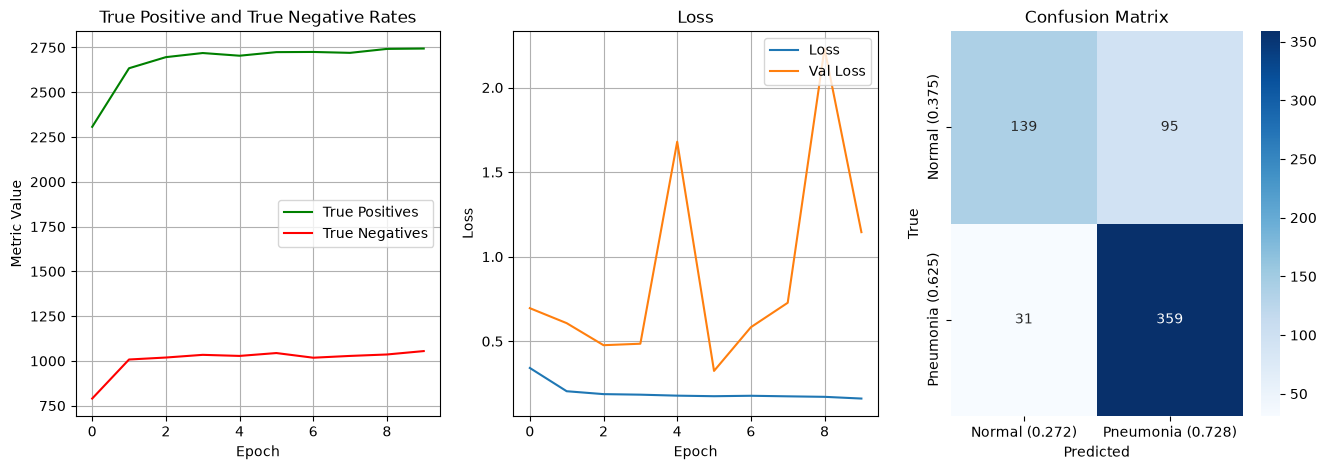

In [7]:
history = model_1.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=make_callbacks("best_model.keras"),
)
best_model = tf.keras.models.load_model("best_model.keras")

In [ ]:
summary_graphics(history, best_model, test_ds)

## Tuning the decision threshold

At the default 0.5 cutoff the model has high precision but low recall (many false
negatives). Here we pick the threshold that maximizes F1 on the **validation** set
and apply it to the **test** set, recovering most of the missed pneumonia cases.

25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 155ms/step
Tuned threshold: 0.569  (default is 0.5)

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 144ms/step
   default 0.5: accuracy=0.798  recall=0.921  precision=0.791  false negatives=31
   tuned 0.569: accuracy=0.812  recall=0.918  precision=0.808  false negatives=32


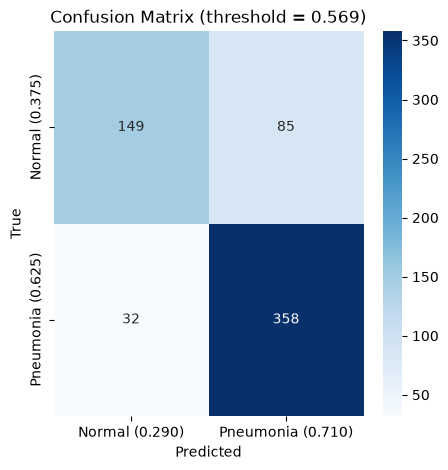

In [8]:
# Choose the decision threshold on the VALIDATION set (never on test), then apply it
# to test. The model has high precision but low recall at the default 0.5 cutoff, so a
# lower threshold trades a little precision for far fewer false negatives.
val_probs = best_model.predict(validation_ds).ravel()
y_val = np.concatenate([y for _, y in validation_ds], axis=0)

precision, recall, thresholds = precision_recall_curve(y_val, val_probs)
f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-9)
threshold = float(thresholds[np.argmax(f1)])
print(f"Tuned threshold: {threshold:.3f}  (default is 0.5)\n")

test_probs = best_model.predict(test_ds).ravel()
y_test = np.concatenate([y for _, y in test_ds], axis=0)

for name, thr in [("default 0.5", 0.5), (f"tuned {threshold:.3f}", threshold)]:
    pred = (test_probs >= thr).astype("int32")
    tp = int(((pred == 1) & (y_test == 1)).sum())
    fn = int(((pred == 0) & (y_test == 1)).sum())
    fp = int(((pred == 1) & (y_test == 0)).sum())
    print(
        f"{name:>14}: accuracy={np.mean(pred == y_test):.3f}  "
        f"recall={tp / (tp + fn):.3f}  precision={tp / (tp + fp):.3f}  "
        f"false negatives={fn}"
    )

fig, ax = plt.subplots(figsize=(5, 5))
plot_binary_confusion_matrix(ax, y_test, (test_probs >= threshold).astype("int32"))
ax.set_title(f"Confusion Matrix (threshold = {threshold:.3f})")
plt.show()

In [9]:
notebook_end_time = datetime.datetime.now()
print(
    f"Notebook last run (end-to-end): {notebook_end_time} (duration: {notebook_end_time - notebook_start_time})"
)

Notebook last run (end-to-end): 2026-06-25 05:20:31.143665 (duration: 0:12:20.086518)
